# Through focus scan of the grating writer head
khchan@lbl.gov, awojdyla@lbl.gov, meericksen@lbl.gov
July 2026

We want to perform a through focus scan of the grating writer head.
The laser is a Coherent Obis 405-100FP at 3mW, The stage is the Newport XML210-S, the camera is a Basler acA5472-5gm (monochrome, 2.4 pixel size). 

We are using a Mitutoyo lens 5x0.14NA with an MT-4 tube lend, a 20um x 10 mm slit and a ND4 neutral density filter.

## connecting to the instruments

### Basler camera

In [1]:
from pypylon import pylon, genicam

def open_camera(device_index=0, exposure_us=1500.0, gain=0.0):
    tl_factory = pylon.TlFactory.GetInstance()
    devices = tl_factory.EnumerateDevices()

    if len(devices) == 0:
        raise RuntimeError("No Basler cameras were found connected to this computer.")

    if device_index >= len(devices):
        raise ValueError(f"Device index {device_index} is out of range. Only {len(devices)} camera(s) found.")

    camera = pylon.InstantCamera(tl_factory.CreateDevice(devices[device_index]))
    camera.Open()

    try:
        camera.ExposureTime.SetValue(float(exposure_us))
    except (genicam.LogicalErrorException, AttributeError):
        try:
            camera.ExposureTimeAbs.SetValue(float(exposure_us))
        except (genicam.LogicalErrorException, AttributeError):
            print("Warning: Could not find a valid ExposureTime node on this camera.")

    try:
        camera.Gain.SetValue(float(gain))
    except (genicam.LogicalErrorException, AttributeError):
        try:
            camera.GainRaw.SetValue(int(gain))
        except (genicam.LogicalErrorException, AttributeError):
            print("Warning: Could not find a valid Gain node on this camera.")

    # Mono sensor: convert straight to 8-bit grayscale, no color channels.
    converter = pylon.ImageFormatConverter()
    converter.OutputPixelFormat = pylon.PixelType_Mono8
    converter.OutputBitAlignment = pylon.OutputBitAlignment_MsbAligned

    return camera, converter

def capture_image(camera, converter):
    """
    Grabs a single frame from the camera and returns it as a numpy array.
    """
    # Start grabbing if the camera isn't already actively streaming
    if not camera.IsGrabbing():
        camera.StartGrabbing(pylon.GrabStrategy_LatestImageOnly)

    grab_result = camera.RetrieveResult(5000, pylon.TimeoutHandling_ThrowException)

    if grab_result.GrabSucceeded():
        image = converter.Convert(grab_result)
        img_array = image.GetArray()
    else:
        grab_result.Release()
        raise RuntimeError("Failed to grab an image from the camera.")

    grab_result.Release()
    return img_array

In [2]:
import os
import time
import uuid
import numpy as np
import tifffile
from datetime import datetime
from collections import OrderedDict

from ophyd import Device, Component as Cpt, Signal
from ophyd.status import Status
from pypylon import genicam


# ============================================================
# Camera Settings (replaces EPICS-based CamBase)
# ============================================================
class BaslerCam(Device):
    """
    Wraps pypylon camera parameters as Ophyd signals.
    Instead of talking to EPICS PVs, get/set operations talk
    directly to the pypylon camera object's node map.
    """
    exposure_time = Cpt(Signal, value=1000.0, kind="config")  # microseconds
    gain = Cpt(Signal, value=0.0, kind="config")
    num_images = Cpt(Signal, value=1, kind="config")

    def __init__(self, *args, camera=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.camera = camera
        self.stage_sigs = OrderedDict()

    def stage(self):
        for sig_name, value in self.stage_sigs.items():
            getattr(self, sig_name).set(value).wait()
        self._apply_to_hardware()
        return super().stage()

    def _apply_to_hardware(self):
        try:
            self.camera.ExposureTime.SetValue(float(self.exposure_time.get()))
        except (genicam.LogicalErrorException, AttributeError):
            self.camera.ExposureTimeAbs.SetValue(float(self.exposure_time.get()))

        try:
            self.camera.Gain.SetValue(float(self.gain.get()))
        except (genicam.LogicalErrorException, AttributeError):
            self.camera.GainRaw.SetValue(int(self.gain.get()))


# ============================================================
# TIFF Writer (replaces FileStoreTIFFIterativeWrite + TIFFPlugin)
# ============================================================
class BaslerTIFFPlugin(Device):
    """Writes TIFF files locally. No Resource/Datum/StreamResource
    documents -- the file path is just recorded as a plain string
    value in the Event stream, not registered as external Tiled data."""

    def __init__(
        self,
        *args,
        write_path_template,
        file_template="%s_%06d.tif",
        **kwargs,
    ):
        super().__init__(*args, **kwargs)
        self.write_path_template = write_path_template
        self.file_template = file_template
        self.stage_sigs = OrderedDict()

        self._write_dir = None
        self._point_number = 0

    def _resolve_path(self, template):
        return datetime.now().strftime(template)

    def stage(self):
        self._write_dir = self._resolve_path(self.write_path_template)
        os.makedirs(self._write_dir, exist_ok=True)
        self._point_number = self._get_next_point_number()
        return super().stage()

    def _get_next_point_number(self):
        prefix = self.parent.name
        existing = [
            f for f in os.listdir(self._write_dir)
            if f.startswith(prefix + "_") and f.endswith(".tif")
        ]
        numbers = []
        for f in existing:
            num_str = f[len(prefix) + 1 : -len(".tif")]
            try:
                numbers.append(int(num_str))
            except ValueError:
                continue
        return max(numbers) + 1 if numbers else 0

    def unstage(self):
        self._write_dir = None
        return super().unstage()

    def write_frame(self, img):
        fname = self.file_template % (self.parent.name, self._point_number)
        filepath = os.path.join(self._write_dir, fname)
        tifffile.imwrite(filepath, img)
        self._point_number += 1
        return filepath


class BaslerDetector(Device):
    def __init__(self, *args, camera, converter, write_dir, **kwargs):
        super().__init__(*args, **kwargs)

        self.cam = BaslerCam(camera=camera, name=f"{self.name}_cam", parent=self)
        self.tiff = BaslerTIFFPlugin(
            write_path_template=write_dir,
            name=f"{self.name}_tiff",
            parent=self,
        )

        self.converter = converter
        self._image_name = f"{self.name}_image_path"
        self._current_path = None
        self._current_shape = None
        self._current_dtype = None

    def stage(self):
        self.cam.stage()
        try:
            height = self.cam.camera.Height.GetValue()
            width = self.cam.camera.Width.GetValue()
            self._current_shape = (height, width)   # mono, no channel dim
            self._current_dtype = np.uint8

            self.tiff.stage()
        except Exception:
            self.cam.unstage()
            raise
        return super().stage()

    def unstage(self):
        self.tiff.unstage()
        self.cam.unstage()
        return super().unstage()

    def trigger(self):
        status = Status()
        try:
            img = capture_image(self.cam.camera, self.converter)
            filepath = self.tiff.write_frame(img)

            self._current_path = filepath
            self._current_shape = img.shape
            self._current_dtype = img.dtype
            status.set_finished()
        except Exception as exc:
            status.set_exception(exc)
        return status

    def read(self):
        # Plain string value -- travels through the normal internal
        # (pyarrow-table) Event path, no external asset machinery.
        return {
            self._image_name: {
                "value": self._current_path,
                "timestamp": time.time(),
            }
        }

    def describe(self):
        return {
            self._image_name: {
                "dtype": "string",
                "shape": [],
                "source": "BaslerDetector",
            }
        }


# ============================================================
# Instantiation
# ============================================================
exposure_time_us = 1500.
gain = 0
camera_hw, converter = open_camera(device_index=1, exposure_us=exposure_time_us, gain=gain)

basler_camera = BaslerDetector(
    camera=camera_hw,
    converter=converter,
    write_dir=r"C:\BlueskyData\BaslerImages\%Y\%m\%d",
    name="basler_camera",
)

basler_camera.cam.stage_sigs["exposure_time"] = exposure_time_us
basler_camera.cam.stage_sigs["gain"] = gain
basler_camera.cam.stage_sigs["num_images"] = 1

### Newport

In [3]:
import time
import threading
from ophyd import Device, Component as Cpt, Signal, SignalRO, Kind
from ophyd.status import DeviceStatus
from newportxps import NewportXPS

class XPSPositionSignal(SignalRO):
    def get(self, **kwargs):
        """Query the hardware directly for the current position."""
        position = self.parent.xps.get_stage_position(self.parent.stage_name)
        self._readback = position
        return position

class NewportXPSStage(Device):
    # Configuration parameters: stored once per run in Tiled's descriptor
    velocity = Cpt(Signal, value=3.0, kind=Kind.config)
    acceleration = Cpt(Signal, value=1.0, kind=Kind.config)
    
    # Hinted: Tiled and standard Bluesky tools will use this as the primary field
    current_position = Cpt(XPSPositionSignal, kind=Kind.hinted)

    def __init__(self, prefix="", *, ip_address, username, password, stage_name, name="xps_stage", **kwargs):
        super().__init__(prefix, name=name, **kwargs)
        self.stage_name = stage_name
        self.xps = NewportXPS(ip_address, username=username, password=password)
        self._done = True  # Track the motion state locally
        
        time.sleep(0.1)
        
        # Apply parameters immediately upon connection
        self._apply_gamma_parameters()

    def _apply_gamma_parameters(self, min_jerk=0.01, max_jerk=0.01):
        """Sends the current velocity and acceleration signals to the controller."""
        self.xps._xps.PositionerSGammaParametersSet(
            self.xps._sid,
            self.stage_name,
            self.velocity.get(),
            self.acceleration.get(),
            min_jerk,
            max_jerk
        )

    def stage(self):
        """Bluesky calls this before a plan starts, ensuring settings are fresh."""
        self._apply_gamma_parameters()
        return super().stage()

    def set(self, target_position):
        """Called by Bluesky (e.g., bps.mv) to move the stage. Returns a status object."""
        status = DeviceStatus(self)
        self._done = False

        def move_thread():
            try:
                # Send the move command via the XPS API
                group_name = self.stage_name.split('.')[0]
                self.xps._xps.GroupMoveAbsolute(self.xps._sid, group_name, [target_position])
                
                # Poll the controller until the motion is complete
                done_status = 0
                while done_status == 0 and not self._done:
                    error_code, done_status = self.xps._xps.PositionerMotionDoneGet(
                        self.xps._sid, 
                        self.stage_name
                    )
                    time.sleep(0.1)  # Avoid flooding the socket with requests
                
                # Mark as finished
                self._done = True
                status.set_finished()
            except Exception as exc:
                self._done = True
                status.set_exception(exc)

        # Run the move in a separate thread so it doesn't block the Bluesky run engine
        threading.Thread(target=move_thread, daemon=True).start()
        return status

    def stop(self, *, success=False):
        """Called by Bluesky if a plan is aborted (e.g., via Ctrl+C)."""
        self._done = True
        try:
            group_name = self.stage_name.split('.')[0]
            self.xps._xps.GroupMoveAbort(self.xps._sid, group_name)
        except Exception as exc:
            print(f"Failed to abort motion on {self.name}: {exc}")
        super().stop(success=success)

    @property
    def position(self):
        """Standard positioner interface: hardware readback."""
        return self.current_position.get()

    @property
    def done(self):
        """Standard positioner interface: True if idle, False if moving."""
        return self._done


# Instantiate your new full-featured Ophyd object
grating_stage = NewportXPSStage(
    ip_address='192.168.10.20',
    username='Administrator',
    password='Administrator',
    stage_name='Group1.Pos',
    name='grating_stage'
)

In [4]:
grating_stage.set(25)

DeviceStatus(device=grating_stage, done=False, success=False)

### Tiled server

In [5]:
from bluesky import RunEngine

RE = RunEngine({})

from bluesky.callbacks.best_effort import BestEffortCallback
from bluesky.callbacks.tiled_writer import TiledWriter
from tiled.server import SimpleTiledServer
from tiled.client import from_uri
#load the api key from env var
import os
api_key = os.getenv("TILED_SINGLE_USER_API_KEY")
if not api_key:
    raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")
api_key = api_key.strip(' \'"“”')
# Initialize the Tiled server and client
tiled_client = from_uri("http://192.168.10.240:8000", api_key=api_key)
tw = TiledWriter(tiled_client)
RE.subscribe(tw)

bec = BestEffortCallback()

bec.disable_plots()

# Send all metadata/data captured to the BestEffortCallback.
RE.subscribe(bec)

1

In [9]:
from bluesky.plans import scan
uid = RE(scan([basler_camera, grating_stage], grating_stage, 25, 27, 2))



Transient Scan ID: 2     Time: 2026-07-17 16:25:14
Persistent Unique Scan ID: '0e2a499b-cc76-4110-a52d-b1adc81be89e'
New stream: 'primary'
+-----------+------------+--------------------------------+
|   seq_num |       time | grating_stage_current_position |
+-----------+------------+--------------------------------+
|         1 | 16:25:14.4 |                         25.000 |
|         2 | 16:25:17.4 |                         27.000 |
+-----------+------------+--------------------------------+
generator scan ['0e2a499b'] (scan num: 2)





In [10]:
db = tiled_client[uid]['primary']

In [12]:
db

<BlueskyEventStream {'grating_stage_current_position', 'basler_camera_image_path', 'time'} stream_name='primary'>

In [13]:
import tifffile
import numpy as np
db = tiled_client[uid]['primary']
paths = db['basler_camera_image_path'].read()  # or however you pulled the paths
images = np.stack([tifffile.imread(p) for p in paths])
distance_mm = db['grating_stage_current_position'].read()

In [16]:
images.shape

(2, 3648, 5472)

In [17]:
from bluesky.plans import scan
uid = RE(scan([basler_camera, grating_stage], grating_stage, 29, 30, 11))



Transient Scan ID: 3     Time: 2026-07-17 16:27:37
Persistent Unique Scan ID: '0ceb7b6d-ea00-464f-81a3-ea593e30776c'
New stream: 'primary'
+-----------+------------+--------------------------------+
|   seq_num |       time | grating_stage_current_position |
+-----------+------------+--------------------------------+
|         1 | 16:27:40.2 |                         29.000 |
|         2 | 16:27:41.0 |                         29.100 |
|         3 | 16:27:41.7 |                         29.200 |
|         4 | 16:27:42.5 |                         29.300 |
|         5 | 16:27:43.3 |                         29.400 |
|         6 | 16:27:44.1 |                         29.500 |
|         7 | 16:27:44.9 |                         29.600 |
|         8 | 16:27:45.6 |                         29.700 |
|         9 | 16:27:46.4 |                         29.800 |
|        10 | 16:27:47.2 |                         29.900 |
|        11 | 16:27:48.0 |                         30.000 |
+-----------+------

In [18]:
uid

('0ceb7b6d-ea00-464f-81a3-ea593e30776c',)

In [19]:
import tifffile
import numpy as np
db = tiled_client[uid]['primary']
paths = db['basler_camera_image_path'].read()  # or however you pulled the paths
images = np.stack([tifffile.imread(p) for p in paths])
distance_mm = db['grating_stage_current_position'].read()

In [21]:
import matplotlib.pyplot as plt


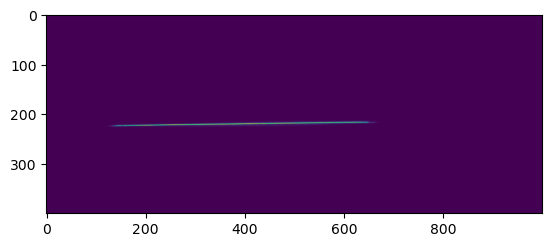

In [37]:
plt.imshow(images[-1,1600:2000,2000:3000])

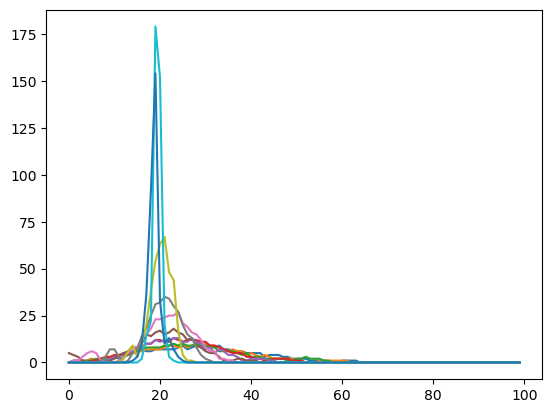

In [35]:
plt.plot(images[:, 1800:1900, 2500].T)

In [38]:
from bluesky.plans import scan
uid = RE(scan([basler_camera, grating_stage], grating_stage, 29.5, 30.5, 101))



Transient Scan ID: 4     Time: 2026-07-17 16:32:26
Persistent Unique Scan ID: '156d01b4-0a76-4dda-9687-1a32c3b32075'
New stream: 'primary'
+-----------+------------+--------------------------------+
|   seq_num |       time | grating_stage_current_position |
+-----------+------------+--------------------------------+
|         1 | 16:32:28.1 |                         29.500 |
|         2 | 16:32:28.4 |                         29.510 |
|         3 | 16:32:28.8 |                         29.520 |
|         4 | 16:32:29.1 |                         29.530 |
|         5 | 16:32:29.5 |                         29.540 |
|         6 | 16:32:29.8 |                         29.550 |
|         7 | 16:32:30.2 |                         29.560 |
|         8 | 16:32:30.5 |                         29.570 |
|         9 | 16:32:30.9 |                         29.580 |
|        10 | 16:32:31.2 |                         29.590 |
|        11 | 16:32:31.6 |                         29.600 |
|        12 | 16:32

In [39]:
uid

('156d01b4-0a76-4dda-9687-1a32c3b32075',)

In [40]:
import tifffile
import numpy as np
db = tiled_client[uid]['primary']
paths = db['basler_camera_image_path'].read()  # or however you pulled the paths
images = np.stack([tifffile.imread(p) for p in paths])
distance_mm = db['grating_stage_current_position'].read()

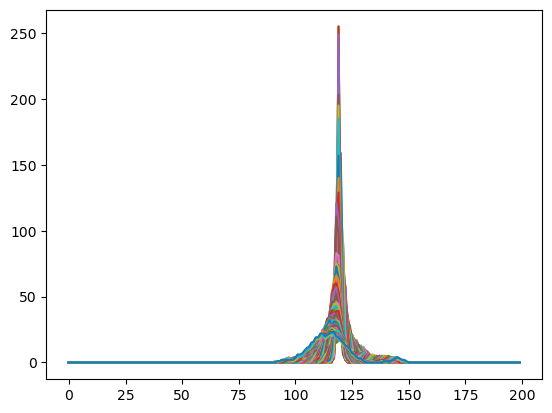

In [42]:
plt.plot(images[:, 1700:1900, 2500].T)

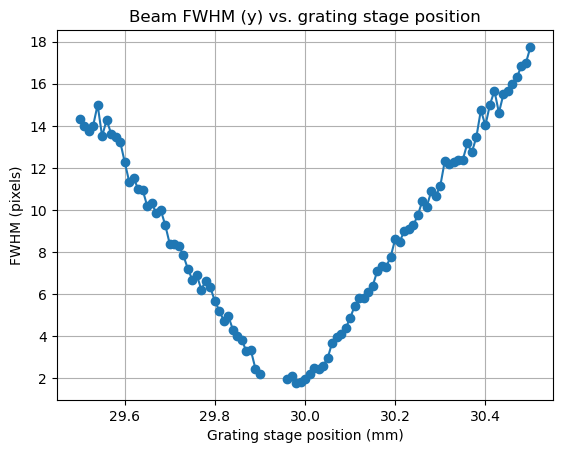

In [43]:
import numpy as np
import matplotlib.pyplot as plt

def compute_fwhm(profile):
    profile = profile.astype(float)
    baseline = profile.min()
    y = profile - baseline          # remove background offset
    half_max = y.max() / 2.0

    above = np.where(y >= half_max)[0]
    if len(above) < 2:
        return np.nan                # peak too weak/narrow to resolve

    left_i, right_i = above[0], above[-1]

    # linear interpolation for sub-pixel crossing points
    if left_i > 0:
        y0, y1 = y[left_i - 1], y[left_i]
        left_x = (left_i - 1) + (half_max - y0) / (y1 - y0)
    else:
        left_x = left_i

    if right_i < len(y) - 1:
        y0, y1 = y[right_i], y[right_i + 1]
        right_x = right_i + (half_max - y0) / (y1 - y0)
    else:
        right_x = right_i

    return right_x - left_x

profiles = images[:, 1700:1900, 2500]          # shape (N, 200)
fwhm_pixels = np.array([compute_fwhm(p) for p in profiles])

distance = np.asarray(distance_mm)

plt.figure()
plt.plot(distance, fwhm_pixels, 'o-')
plt.xlabel('Grating stage position (mm)')
plt.ylabel('FWHM (pixels)')
plt.title('Beam FWHM (y) vs. grating stage position')
plt.grid(True)
plt.show()

Best focus at distance = 29.9572 mm, predicted FWHM = 0.62 pixels


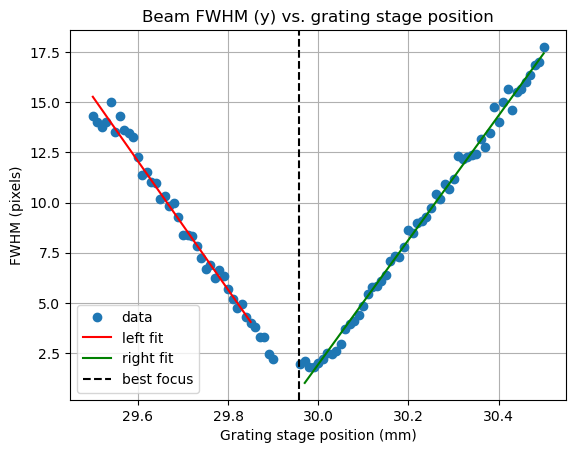

In [44]:
import numpy as np
import matplotlib.pyplot as plt

distance = np.asarray(distance_mm)
fwhm = fwhm_pixels

# sort by distance in case scan wasn't monotonic
order = np.argsort(distance)
distance = distance[order]
fwhm = fwhm[order]

# rough location of the minimum, used to split into left/right arms
min_idx = np.argmin(fwhm)

# exclude a small window right around the minimum -- the curve flattens/rounds
# there and including those points would bias the linear fits
exclude = 5  # points on each side of the vertex to exclude from fitting
left_mask = np.arange(len(distance)) < (min_idx - exclude)
right_mask = np.arange(len(distance)) > (min_idx + exclude)

# fit each arm to a line: fwhm = m*distance + b
m_left, b_left = np.polyfit(distance[left_mask], fwhm[left_mask], 1)
m_right, b_right = np.polyfit(distance[right_mask], fwhm[right_mask], 1)

# intersection of the two lines
best_focus_distance = (b_right - b_left) / (m_left - m_right)
best_focus_fwhm = m_left * best_focus_distance + b_left

print(f"Best focus at distance = {best_focus_distance:.4f} mm, "
      f"predicted FWHM = {best_focus_fwhm:.2f} pixels")

# plot everything to sanity-check the fit
plt.figure()
plt.plot(distance, fwhm, 'o', label='data')
plt.plot(distance[left_mask], m_left*distance[left_mask] + b_left, 'r-', label='left fit')
plt.plot(distance[right_mask], m_right*distance[right_mask] + b_right, 'g-', label='right fit')
plt.axvline(best_focus_distance, color='k', linestyle='--', label='best focus')
plt.xlabel('Grating stage position (mm)')
plt.ylabel('FWHM (pixels)')
plt.title('Beam FWHM (y) vs. grating stage position')
plt.legend()
plt.grid(True)
plt.show()

In [48]:
np.argmin(np.abs(distance - 29.96))

np.int64(46)

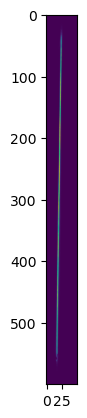

In [59]:
plt.imshow(images[46, 1800:1850, 2100:2700].T)

Text(0, 0.5, 'intensity (au)')

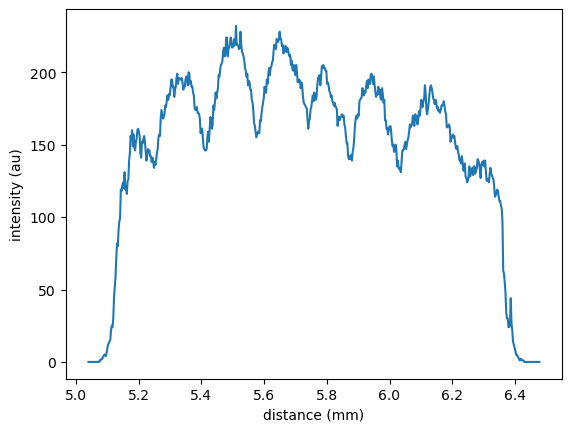

In [61]:
plt.plot(np.arange(2100,2700)*2.4/1000, np.max(images[46, 1800:1850, 2100:2700], 0))
plt.xlabel('distance (mm)')
plt.ylabel('intensity (au)')

six period equal to 0.996 mm
one period equal to 0.166 mm


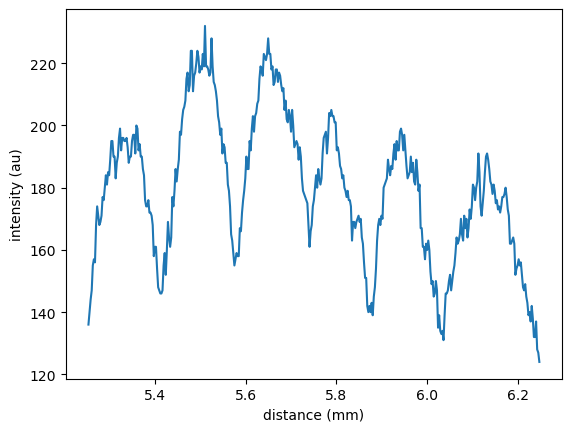

In [96]:
plt.plot(np.arange(2189, 2604) * 2.4 / 1000, np.max(images[46, 1800:1850, 2189:2604], 0))
plt.xlabel('distance (mm)')
plt.ylabel('intensity (au)')
print('six period equal to', (2604 - 2189) * 2.4/1000, 'mm')
print('one period equal to', (2604 - 2189) * 2.4/1000 / 6, 'mm')

In [63]:
import numpy as np

def beam_covariance(img, subtract_background=True):
    img = img.astype(float)

    if subtract_background:
        # simple background estimate -- median of the crop, or better,
        # median of a known background region outside the beam
        background = np.median(img)
        img = img - background
        img[img < 0] = 0  # clip negative noise after subtraction

    ny, nx = img.shape
    y_idx, x_idx = np.mgrid[0:ny, 0:nx]

    total_intensity = img.sum()
    if total_intensity == 0:
        raise ValueError("Total intensity is zero after background subtraction")

    # weighted centroid
    x_mean = (x_idx * img).sum() / total_intensity
    y_mean = (y_idx * img).sum() / total_intensity

    # weighted second moments
    dx = x_idx - x_mean
    dy = y_idx - y_mean

    var_x = (dx**2 * img).sum() / total_intensity
    var_y = (dy**2 * img).sum() / total_intensity
    cov_xy = (dx * dy * img).sum() / total_intensity

    cov_matrix = np.array([[var_x, cov_xy],
                            [cov_xy, var_y]])

    return cov_matrix, (x_mean, y_mean)

crop = images[46, 1800:1850, 2100:2700]
cov, centroid = beam_covariance(crop)

print("Centroid (x, y):", centroid)
print("Covariance matrix:\n", cov)

sigma_x = np.sqrt(cov[0, 0])
sigma_y = np.sqrt(cov[1, 1])
print(f"sigma_x = {sigma_x:.2f} px, sigma_y = {sigma_y:.2f} px")

eigenvalues, eigenvectors = np.linalg.eigh(cov)
sigma_major = np.sqrt(eigenvalues.max())
sigma_minor = np.sqrt(eigenvalues.min())

# angle of the major axis relative to x-axis, in degrees
major_axis = eigenvectors[:, np.argmax(eigenvalues)]
angle_deg = np.degrees(np.arctan2(major_axis[1], major_axis[0]))

print(f"sigma_major = {sigma_major:.2f} px, sigma_minor = {sigma_minor:.2f} px, angle = {angle_deg:.1f} deg")

Centroid (x, y): (np.float64(298.07775056633807), np.float64(20.495683585379293))
Covariance matrix:
 [[ 2.05101953e+04 -2.87451544e+02]
 [-2.87451544e+02  4.69280265e+00]]
sigma_x = 143.21 px, sigma_y = 2.17 px
sigma_major = 143.23 px, sigma_minor = 0.81 px, angle = 179.2 deg


Text(0, 0.5, 'intensity (au)')

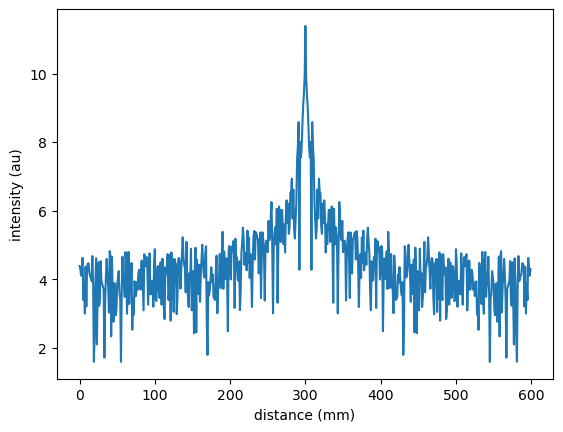

In [66]:
plt.plot(np.log(np.abs(np.fft.fftshift(np.fft.fft(np.max(images[46, 1800:1850, 2100:2700], 0))))))
plt.xlabel('distance (mm)')
plt.ylabel('intensity (au)')

In [ ]:
import numpy as np

crop = images[46, 1800:1850, 2100:2700].astype(float)
ny, nx = crop.shape

background = np.median(crop)
crop_bg = np.clip(crop - background, 0, None)

rows = np.arange(ny)
col_sum = crop_bg.sum(axis=0)
valid = col_sum > (0.05 * col_sum.max())   # ignore columns with negligible signal

y_centroid = np.full(nx, np.nan)
y_centroid[valid] = (rows[:, None] * crop_bg[:, valid]).sum(axis=0) / col_sum[valid]

x_idx = np.arange(nx)
slope, intercept = np.polyfit(x_idx[valid], y_centroid[valid], 1, w=col_sum[valid])

print(f"tilt slope = {slope:.5f} px/px, angle = {np.degrees(np.arctan(slope)):.3f} deg")

tilt slope = -0.01404 px/px, angle = -0.805 deg


Text(0.5, 1.0, 'Oversampled line spread function')

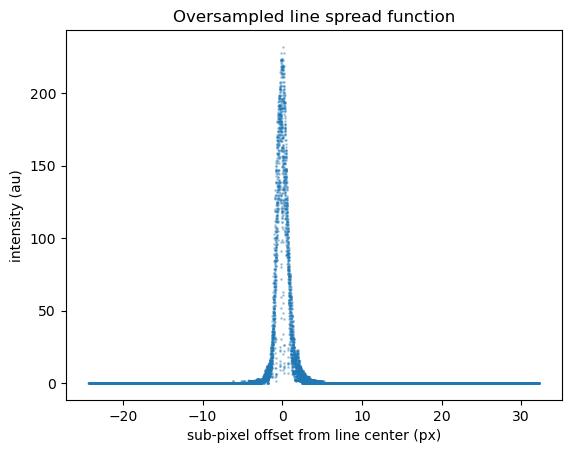

In [68]:
offsets, intensities = [], []
for xi in np.where(valid)[0]:
    y_pred = slope * xi + intercept
    offsets.append(rows - y_pred)
    intensities.append(crop_bg[:, xi])

offsets = np.concatenate(offsets)
intensities = np.concatenate(intensities)

order = np.argsort(offsets)
offsets, intensities = offsets[order], intensities[order]

import matplotlib.pyplot as plt
plt.plot(offsets, intensities, '.', ms=2, alpha=0.3)
plt.xlabel('sub-pixel offset from line center (px)')
plt.ylabel('intensity (au)')
plt.title('Oversampled line spread function')

In [69]:
from scipy.optimize import curve_fit
from scipy.special import erf

def pixel_integrated_gaussian(y, amplitude, y0, sigma, baseline):
    return baseline + amplitude / 2 * (
        erf((y - y0 + 0.5) / (np.sqrt(2) * sigma)) -
        erf((y - y0 - 0.5) / (np.sqrt(2) * sigma))
    )

p0 = [intensities.max(), 0, 0.5, 0]
popt, _ = curve_fit(pixel_integrated_gaussian, offsets, intensities, p0=p0)
amplitude, y0, sigma, baseline = popt

fwhm_px = 2 * np.sqrt(2 * np.log(2)) * sigma
print(f"deconvolved sigma = {sigma:.3f} px, FWHM = {fwhm_px:.3f} px "
      f"({fwhm_px * 2.4:.3f} um at 2.4 um/px)")

deconvolved sigma = 0.591 px, FWHM = 1.393 px (3.343 um at 2.4 um/px)


In [70]:
pixel_pitch_um = 2.4

alias_period_px = 1 / abs(slope)          # pixels of x for one full sub-pixel phase cycle in y
alias_period_mm = alias_period_px * pixel_pitch_um / 1000
print(f"predicted alias ripple period: {alias_period_mm:.3f} mm")

predicted alias ripple period: 0.171 mm


In [71]:
from scipy.optimize import curve_fit
from scipy.special import erf

def pixel_integrated_gaussian_with_fill_factor(y, amplitude, y0, sigma, fill_width, baseline):
    # fill_width = active region width as a fraction of the pixel pitch (fill factor),
    # centered within each pixel cell -- fill_width = 1.0 means no gap (100% fill factor)
    half_w = fill_width / 2
    return baseline + amplitude / 2 * (
        erf((y - y0 + half_w) / (np.sqrt(2) * sigma)) -
        erf((y - y0 - half_w) / (np.sqrt(2) * sigma))
    )

p0 = [intensities.max(), 0, 0.5, 0.8, 0]  # initial guess: fill_width ~0.8 (80% fill factor)
popt, pcov = curve_fit(
    pixel_integrated_gaussian_with_fill_factor, offsets, intensities, p0=p0,
    bounds=([0, -2, 0.01, 0.01, -np.inf], [np.inf, 2, 5, 1.0, np.inf])
)
amplitude, y0, sigma, fill_width, baseline = popt

fwhm_px = 2 * np.sqrt(2 * np.log(2)) * sigma
print(f"beam sigma = {sigma:.3f} px, FWHM = {fwhm_px:.3f} px")
print(f"fitted fill factor = {fill_width:.2f} (active width as fraction of pixel pitch)")

beam sigma = 0.591 px, FWHM = 1.393 px
fitted fill factor = 1.00 (active width as fraction of pixel pitch)
